Online Retail Sales Analysis

Internship Project – Zidio Development

Objective:
To analyze online retail transaction data, identify sales trends, understand customer behavior, and generate business insights using Python and data analytics techniques.


Dataset Information

Dataset Name: Online Retail II

Source: UCI Machine Learning Repository

Description:
The dataset contains transactional data from a UK-based online retail store, including invoices, products, quantities, prices, customers, and countries.

Period Covered:
December 2010 – December 2011

1. EDA & Data Cleaning

In [1]:
!pip install pandas numpy matplotlib seaborn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

In [4]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
excel_file = pd.ExcelFile("online_retail_II.xlsx")
print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [6]:
df.shape

(541910, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


In [11]:
df.duplicated().sum()

np.int64(5268)

In [12]:
print("Before Cleaning:", df.shape)

Before Cleaning: (541910, 8)


In [13]:
df = df.drop_duplicates()

In [14]:

print("After Removing Duplicates:", df.shape)

After Removing Duplicates: (536642, 8)


In [15]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135037
Country,0


In [16]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135037
Country,0


In [17]:
df = df.dropna(subset=["Customer ID"])

In [18]:
df = df.dropna(subset=["Description"])

In [19]:
df = df[df["Quantity"] > 0]

In [20]:
df = df[df["Price"] > 0]

In [21]:
print(df.shape)

(392693, 8)


In [22]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [23]:

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [24]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
Revenue,0


In [25]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,392693.000000,392693,392693.000000,392693.000000,392693.000000
mean,13.119671,2011-07-10 19:13:41.156272128,3.125952,15287.837224,22.631488
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492603,NaN,22.241820,1713.542421,311.098828


In [26]:
df["Revenue"].sum()

np.float64(8887226.894000003)

In [27]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

In [28]:
top_customers = df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False).head(10)

In [29]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

In [30]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.month)["Revenue"].sum()

In [31]:
df.shape

(392693, 9)

In [32]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,392693.000000,392693,392693.000000,392693.000000,392693.000000
mean,13.119671,2011-07-10 19:13:41.156272128,3.125952,15287.837224,22.631488
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492603,NaN,22.241820,1713.542421,311.098828


top 10 products

In [33]:

top_products

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


Top 10 Customers


In [34]:
 top_customers

,Revenue
Customer ID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


Top 10 Countries

In [35]:

country_sales

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208952.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


monthly revenue

In [36]:
monthly_sales

,Revenue
InvoiceDate,
1,568101.310
2,446084.920
3,594081.760
4,468374.331
5,677355.150
6,660046.050
7,598962.901
8,644051.040
9,950690.202


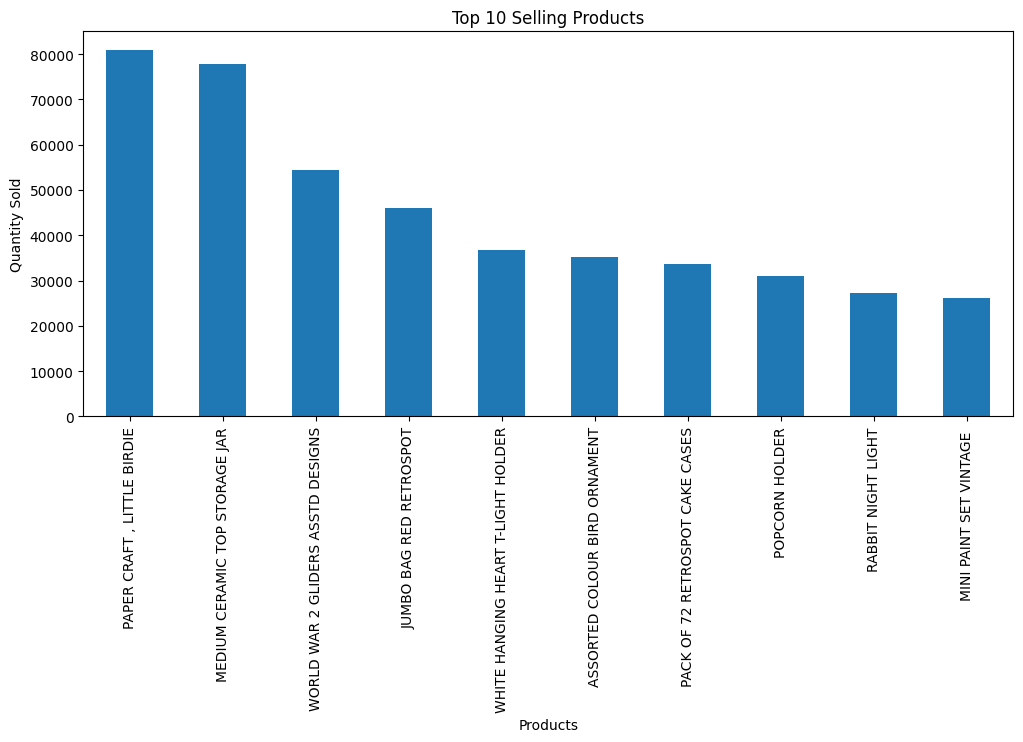

In [37]:
plt.figure(figsize=(12,5))
top_products.plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.show()

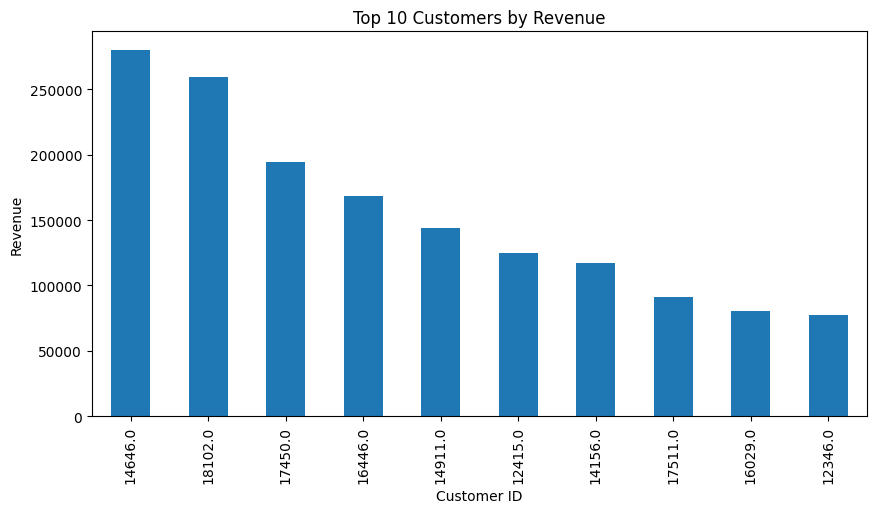

In [38]:
plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

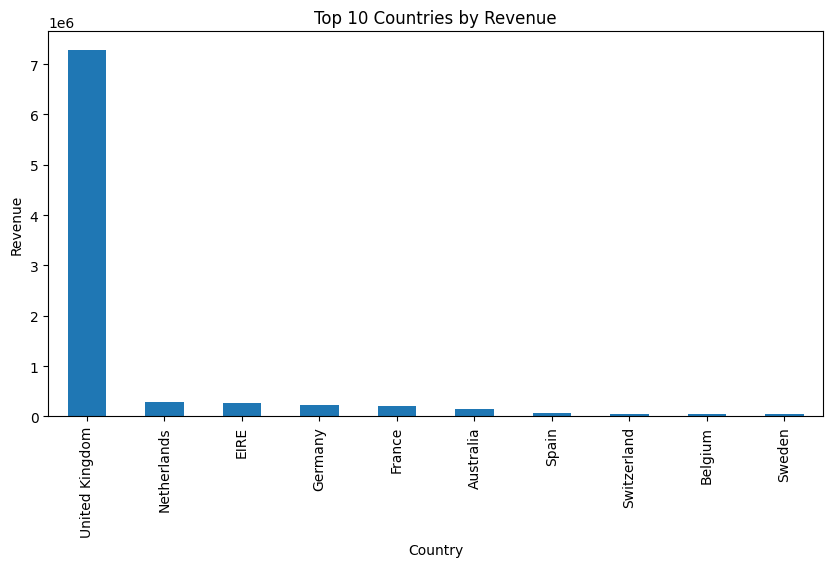

In [39]:
plt.figure(figsize=(10,5))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

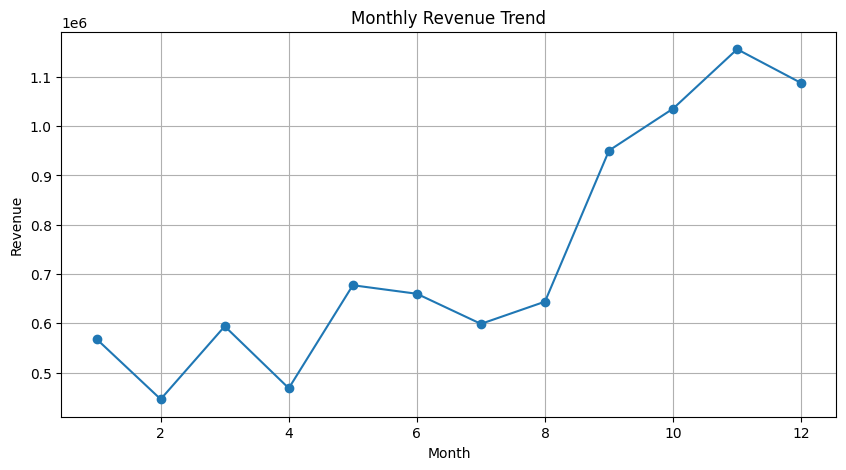

In [40]:
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

Business Insights

1. The United Kingdom generated the highest revenue among all countries.

2. A few products contributed significantly to overall sales volume.

3. Top customers generated a large percentage of total revenue.

4. Sales increased significantly during the last quarter of the year.

5. The business shows strong seasonal trends, with peak sales occurring in November.

6. Customer-focused marketing campaigns can be designed for high-value customers.

7. Inventory planning should prioritize the top-selling products.

Conclusion

The Online Retail dataset was analyzed to understand sales performance, customer behavior, and product demand.

After cleaning the data and removing missing values, duplicates, and invalid records, revenue analysis was performed.

The analysis revealed that the United Kingdom is the dominant market, a small group of customers contributes significantly to revenue, and sales show seasonal growth towards the end of the year.

These insights can help businesses improve marketing strategies, inventory management, and customer retention.

2 Customer Segmentation

In [134]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')

In [135]:
snapshot_date = df["InvoiceDate"].max()

snapshot_date = snapshot_date + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [136]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')

In [137]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "count",
    "Revenue": "sum"
})

In [138]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [139]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [140]:
rfm.shape

(4338, 3)

In [141]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [142]:
from sklearn.preprocessing import StandardScaler

In [143]:
scaler = StandardScaler()

In [144]:
rfm_scaled = scaler.fit_transform(rfm)

In [145]:
rfm_scaled

array([[ 2.33457414e+00, -3.97035669e-01,  8.36301041e+00],
       [-9.05340320e-01,  4.05692949e-01,  2.51698458e-01],
       [-1.75359593e-01, -2.63986727e-01, -2.79882904e-02],
       ...,
       [-8.45341904e-01, -3.48251057e-01, -2.08214809e-01],
       [-8.85340848e-01,  2.79613895e+00, -3.51977046e-04],
       [-4.95351144e-01, -9.10231019e-02, -2.35315745e-02]])

In [146]:
from sklearn.cluster import KMeans

In [147]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

In [148]:
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [149]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,1
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,0
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,2


In [150]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,1
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,0
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,2


In [151]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,3242
2,1078
1,14
3,4


In [152]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,41.443245,101.011413,1943.361565
1,31.000000,915.857143,121183.096429
2,247.330241,27.386827,563.855622
3,2.000000,5717.250000,70612.247500


In [153]:
segment_names = {
    0: "VIP Customers",
    1: "Loyal Customers",
    2: "Regular Customers",
    3: "At Risk Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [154]:
rfm["Segment"].value_counts()

,count
Segment,
VIP Customers,3242
Regular Customers,1078
Loyal Customers,14
At Risk Customers,4


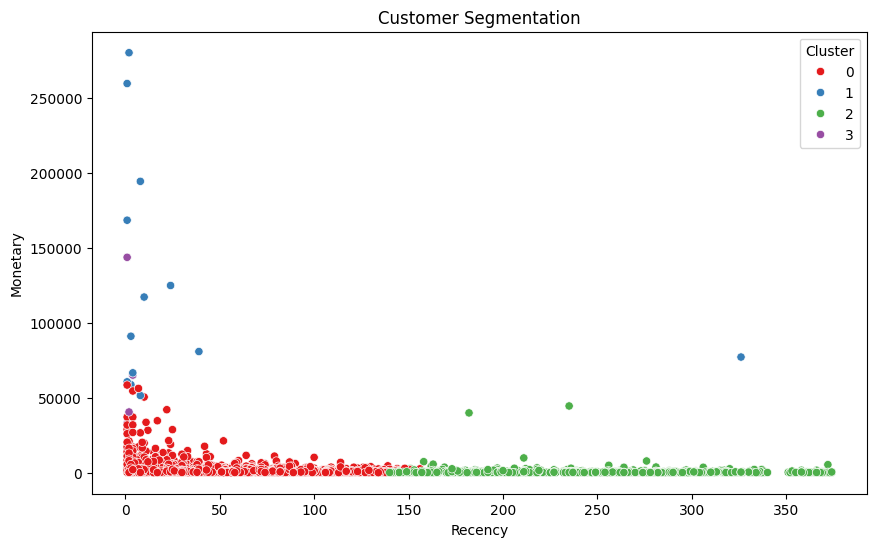

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segmentation")
plt.show()

In [156]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,3242
2,1078
1,14
3,4


In [159]:
rfm.drop('Segment', axis=1).groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,41.443245,101.011413,1943.361565
1,31.000000,915.857143,121183.096429
2,247.330241,27.386827,563.855622
3,2.000000,5717.250000,70612.247500


Customer Segmentation Insights

1. Cluster 3 represents Super VIP customers with the highest purchase frequency and spending.

2. Cluster 1 contains VIP customers who contribute significant revenue.

3. Cluster 0 contains the majority of customers and represents regular active buyers.

4. Cluster 2 contains at-risk customers with low spending and long inactivity periods.

5. Marketing efforts should focus on retaining VIP customers and re-engaging at-risk customers.

3. Demand Forecasting

In [63]:
!pip install prophet

In [64]:
daily_sales = df.groupby("InvoiceDate")["Revenue"].sum().reset_index()

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


In [65]:
daily_sales.columns = ["ds", "y"]

daily_sales.head()

,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


In [66]:
!pip install prophet

In [67]:
daily_sales = df.groupby("InvoiceDate")["Revenue"].sum().reset_index()

daily_sales.columns = ["ds", "y"]

daily_sales.head()

,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


In [68]:
daily_sales = df.groupby(
    df["InvoiceDate"].dt.date
)["Revenue"].sum().reset_index()

daily_sales.columns = ["ds", "y"]

daily_sales.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [69]:
from prophet import Prophet

In [70]:
model = Prophet()

In [71]:
model.fit(daily_sales)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [72]:
future = model.make_future_dataframe(
    periods=30
)

In [73]:
forecast = model.predict(future)

In [74]:
forecast[["ds","yhat"]].tail(10)

,ds,yhat
325,2011-12-30,55147.176355
326,2011-12-31,67172.746555
327,2012-01-01,41983.391801
328,2012-01-02,55206.013546
329,2012-01-03,59375.370485
330,2012-01-04,56838.795122
331,2012-01-05,64292.078034
332,2012-01-06,56504.425108
333,2012-01-07,68529.995308
334,2012-01-08,43340.640553


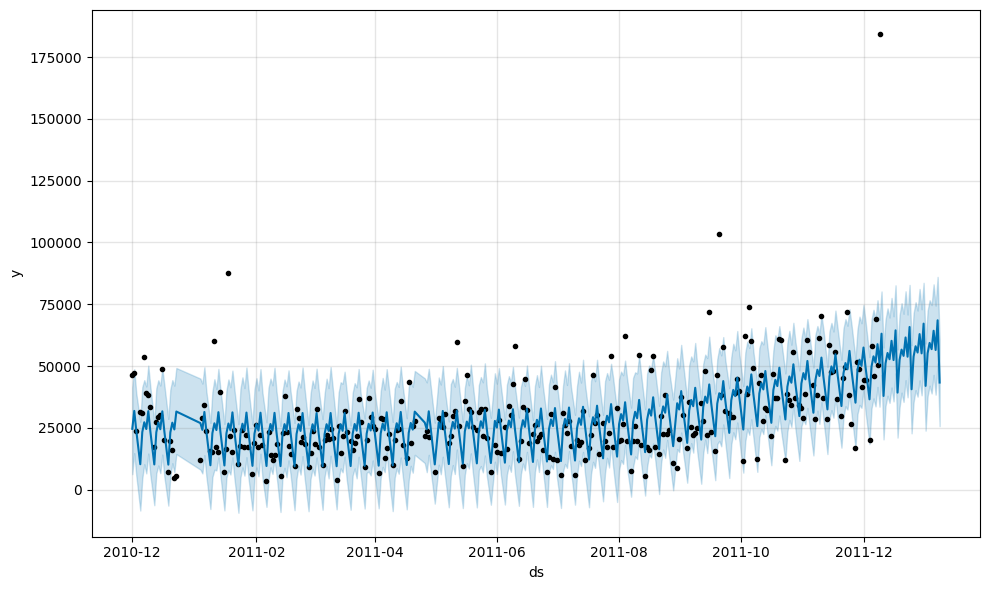

In [75]:
fig = model.plot(forecast)

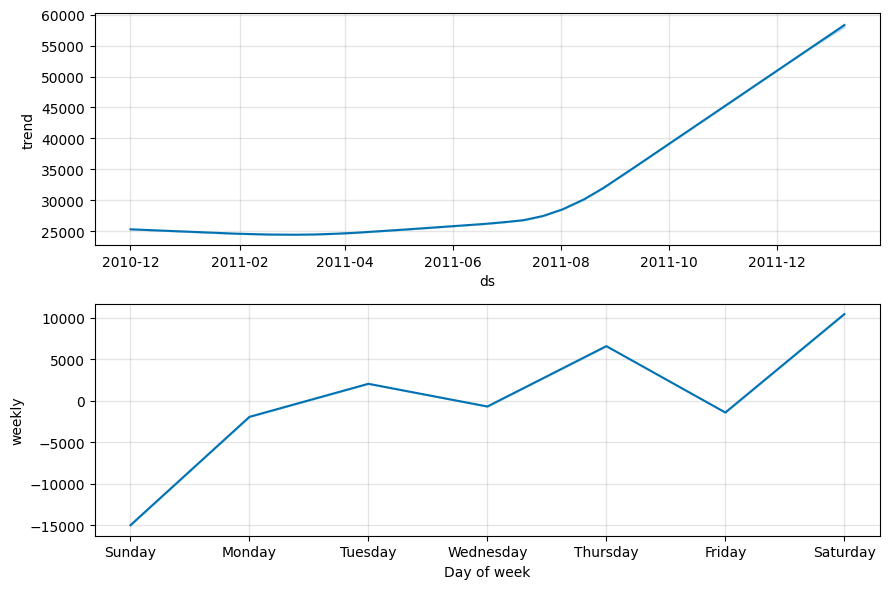

In [76]:
fig2 = model.plot_components(forecast)

Demand Forecasting Insights

1. Prophet model was used to forecast future sales.

2. The model predicts daily sales for the next 30 days.

3. Forecast results indicate expected revenue between approximately 40,000 and 70,000 units per day.

4. Forecasting helps businesses plan inventory and resource allocation.

5. The forecast can support demand-driven decision making.

4. Inventory Optimization

In [77]:
recommended_stock = forecast["yhat"].tail(30).sum()

recommended_stock

np.float64(1660357.470855607)

In [78]:
print("Recommended Inventory for Next 30 Days:")
print(round(recommended_stock))

Recommended Inventory for Next 30 Days:
1660357


Inventory Optimization Insights

1. Future demand was estimated using the forecasting model.

2. Recommended inventory levels were calculated from predicted sales.

3. Maintaining inventory close to forecast demand can reduce stockouts.

4. Inventory optimization can improve operational efficiency and customer satisfaction.

5. Demand forecasting and inventory planning help reduce excess stock costs.

In [79]:
recommended_stock = forecast["yhat"].tail(30).sum()

print(round(recommended_stock))

1660357


In [80]:
# ==================================
# CHURN PREDICTION
# ==================================

In [81]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_recency = (
    df.groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index()
)

customer_recency["Recency"] = (
    snapshot_date -
    customer_recency["InvoiceDate"]
).dt.days

customer_recency["Churn"] = (
    customer_recency["Recency"] > 90
).astype(int)

customer_recency.head()

,Customer ID,InvoiceDate,Recency,Churn
0,12346.0,2011-01-18 10:01:00,326,1
1,12347.0,2011-12-07 15:52:00,2,0
2,12348.0,2011-09-25 13:13:00,75,0
3,12349.0,2011-11-21 09:51:00,19,0
4,12350.0,2011-02-02 16:01:00,310,1


In [82]:
customer_features = df.groupby("Customer ID").agg({
    "Invoice":"count",
    "Revenue":"sum"
}).reset_index()

customer_features.columns = [
    "Customer ID",
    "Frequency",
    "Monetary"
]

customer_features.head()

,Customer ID,Frequency,Monetary
0,12346.0,1,77183.60
1,12347.0,182,4310.00
2,12348.0,31,1797.24
3,12349.0,73,1757.55
4,12350.0,17,334.40


In [83]:
churn_df = customer_features.merge(
    customer_recency[
        ["Customer ID","Recency","Churn"]
    ],
    on="Customer ID"
)

churn_df.head()

,Customer ID,Frequency,Monetary,Recency,Churn
0,12346.0,1,77183.60,326,1
1,12347.0,182,4310.00,2,0
2,12348.0,31,1797.24,75,0
3,12349.0,73,1757.55,19,0
4,12350.0,17,334.40,310,1


In [84]:
from sklearn.model_selection import train_test_split

X = churn_df[["Frequency", "Monetary", "Recency"]]
y = churn_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3470, 3)
(868, 3)


In [85]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [86]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 1, 0, 0, 1, 0, 1, 1, 1, 1])

In [87]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [88]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       561
           1       1.00      1.00      1.00       307

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



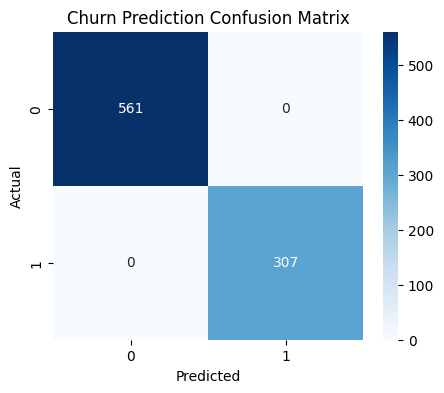

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Churn Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [160]:
high_risk_customers = churn_df[
    churn_df["Churn"] == 1
]

high_risk_customers.head(10)

,Customer ID,Frequency,Monetary,Recency,Churn
0,12346.0,1,77183.60,326,1
4,12350.0,17,334.40,310,1
6,12353.0,4,89.00,204,1
7,12354.0,58,1079.40,232,1
8,12355.0,13,459.40,214,1
14,12361.0,10,189.90,287,1
16,12363.0,23,552.00,110,1
18,12365.0,22,641.38,291,1
23,12373.0,14,364.60,311,1
26,12377.0,77,1628.12,315,1


In [161]:
print("Customers marked as 1 are likely to churn.")
print("These customers have not purchased recently.")
print("Targeted offers can help retain them.")

Customers marked as 1 are likely to churn.
These customers have not purchased recently.
Targeted offers can help retain them.


In [90]:
"Customer Segmentation"


'Customer Segmentation'

In [91]:
"Churn Dashboard"

'Churn Dashboard'